# Лабораторная работа: линейная регрессия

**Датасет:** Concrete Compressive Strength.

**Цель:** построить модели линейной и ridge-регрессии для прогнозирования прочности бетона на сжатие, оценить качество моделей, исследовать мультиколлинеарность и сравнить исходные признаки с главными компонентами PCA.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12

RANDOM_STATE = 42
DATA_PATH = Path("data") / "Concrete_Data.xls"
TARGET = "Concrete_Strength"

## 1. Загрузка и первичный анализ данных

В исходном файле 8 количественных факторов состава/возраста бетона и 1 количественная целевая переменная: прочность бетона на сжатие, MPa.

In [2]:
raw_df = pd.read_excel(DATA_PATH)

column_names = [
    "Cement",
    "Blast_Furnace_Slag",
    "Fly_Ash",
    "Water",
    "Superplasticizer",
    "Coarse_Aggregate",
    "Fine_Aggregate",
    "Age",
    TARGET,
]
df = raw_df.copy()
df.columns = column_names

print(f"Размер датасета: {df.shape[0]} наблюдений, {df.shape[1]} столбцов")
print(f"Дубликаты строк: {df.duplicated().sum()}")
display(df.head())

Размер датасета: 1030 наблюдений, 9 столбцов
Дубликаты строк: 25


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
info_table = pd.DataFrame({
    "Тип данных": df.dtypes.astype(str),
    "Пропуски": df.isna().sum(),
    "Доля пропусков, %": (df.isna().mean() * 100).round(2),
    "Уникальных значений": df.nunique(),
})
display(info_table)

,Тип данных,Пропуски,"Доля пропусков, %",Уникальных значений
Cement,float64,0,0.0,280
Blast_Furnace_Slag,float64,0,0.0,187
Fly_Ash,float64,0,0.0,163
Water,float64,0,0.0,205
Superplasticizer,float64,0,0.0,155
Coarse_Aggregate,float64,0,0.0,284
Fine_Aggregate,float64,0,0.0,304
Age,int64,0,0.0,14
Concrete_Strength,float64,0,0.0,938


In [4]:
display(df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.166,104.507,102.000,192.375,272.900,350.000,540.000
Blast_Furnace_Slag,1030.0,73.895,86.279,0.000,0.000,22.000,142.950,359.400
Fly_Ash,1030.0,54.187,63.996,0.000,0.000,0.000,118.270,200.100
Water,1030.0,181.566,21.356,121.750,164.900,185.000,192.000,247.000
Superplasticizer,1030.0,6.203,5.973,0.000,0.000,6.350,10.160,32.200
Coarse_Aggregate,1030.0,972.919,77.754,801.000,932.000,968.000,1029.400,1145.000
Fine_Aggregate,1030.0,773.579,80.175,594.000,730.950,779.510,824.000,992.600
Age,1030.0,45.662,63.170,1.000,7.000,28.000,56.000,365.000
Concrete_Strength,1030.0,35.818,16.706,2.332,23.707,34.443,46.136,82.599


## 2. Визуализация распределений

Ниже показаны распределения всех признаков и целевой переменной. Это помогает заметить асимметрию, выбросы и разные масштабы признаков.

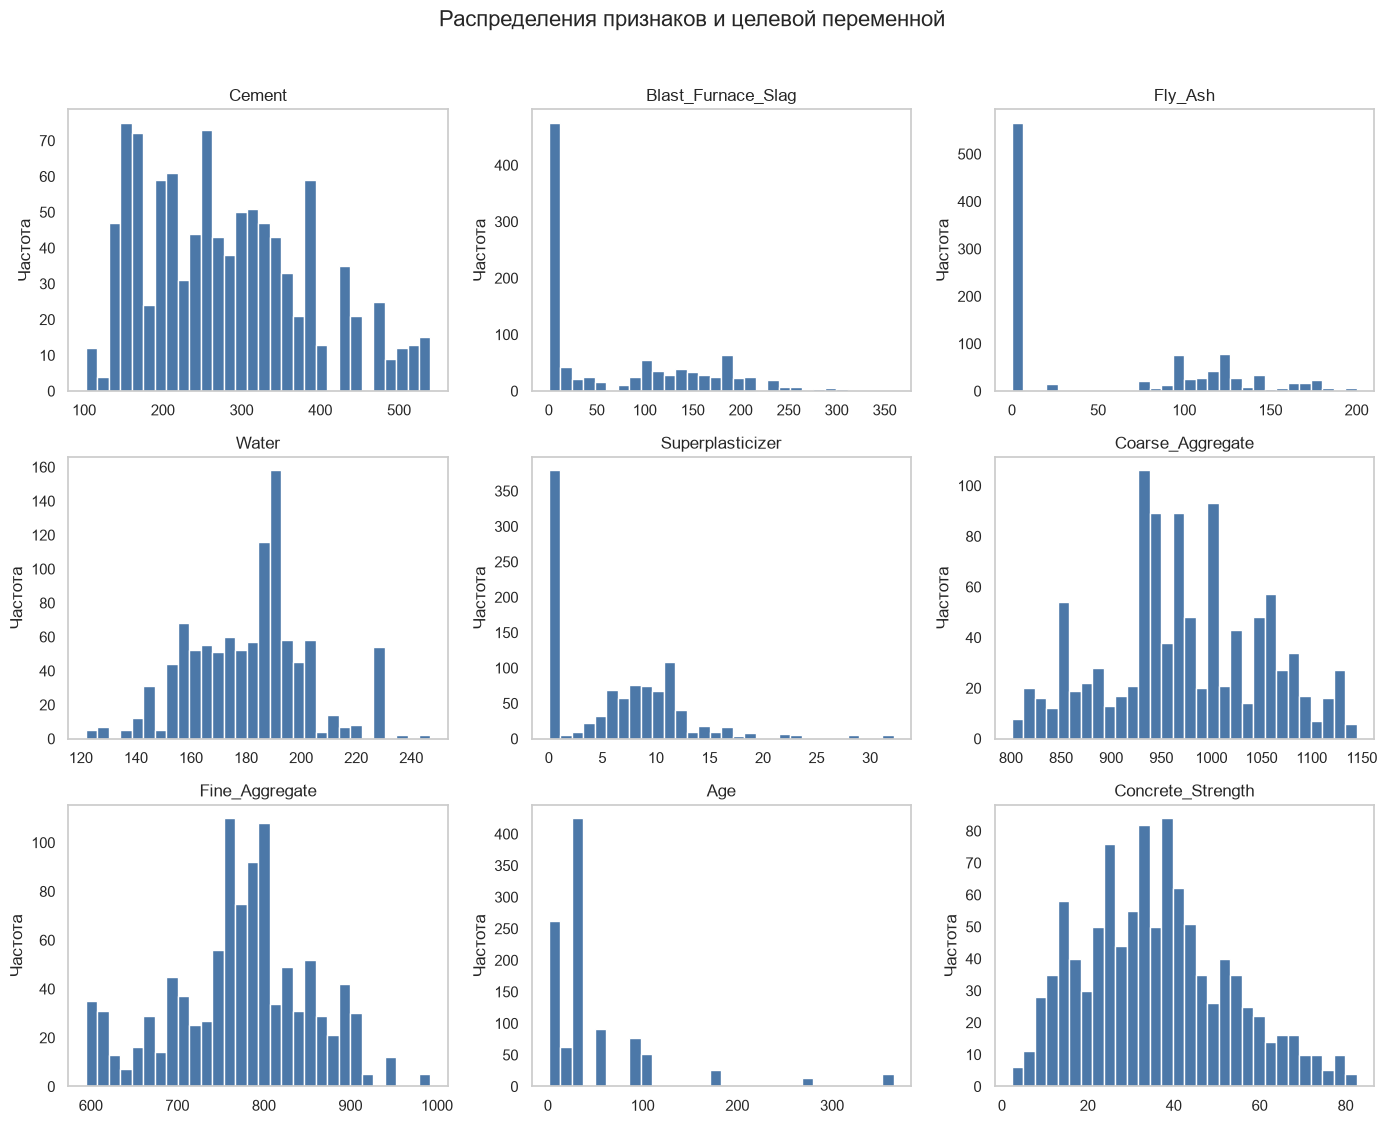

In [5]:
axes = df.hist(
    bins=30,
    figsize=(14, 11),
    color="#4C78A8",
    edgecolor="white",
    grid=False,
)
for ax in axes.ravel():
    ax.set_xlabel("")
    ax.set_ylabel("Частота")
plt.suptitle("Распределения признаков и целевой переменной", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

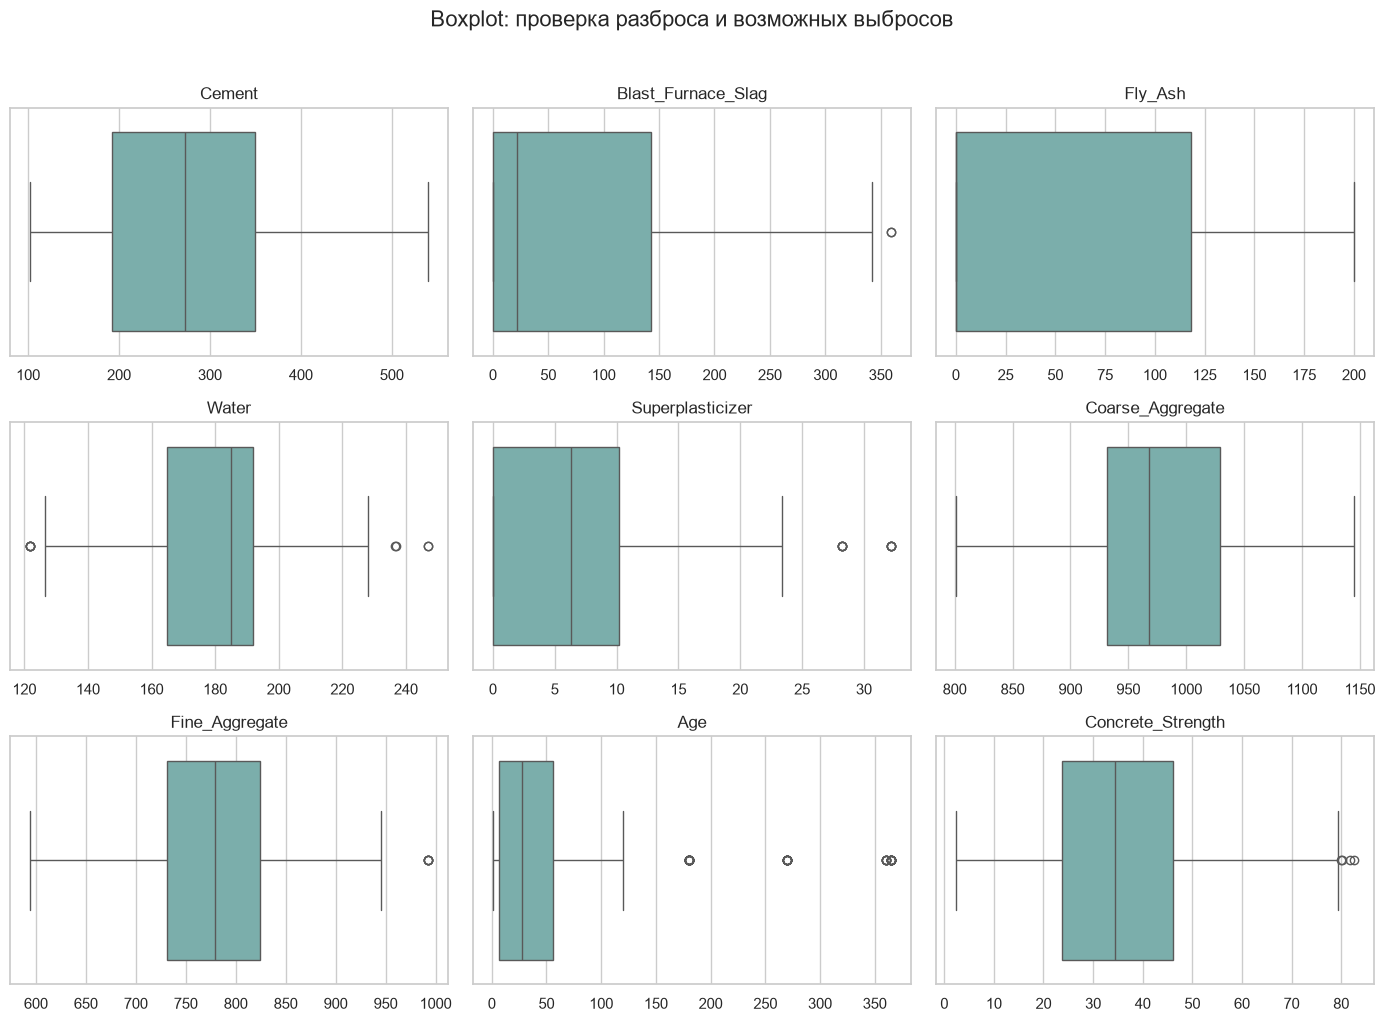

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()
for ax, col in zip(axes, df.columns):
    sns.boxplot(x=df[col], ax=ax, color="#72B7B2")
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes[len(df.columns):]:
    ax.set_visible(False)
plt.suptitle("Boxplot: проверка разброса и возможных выбросов", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 3. Предобработка данных

По описанию датасета пропусков нет, но проверка и удаление пропущенных значений включены в пайплайн. Категориальных признаков в наборе нет, поэтому кодирование не требуется.

In [7]:
data = df.dropna().copy()

categorical_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

print(f"Удалено строк с пропусками: {len(df) - len(data)}")
print(f"Категориальные признаки: {categorical_cols if categorical_cols else 'нет'}")

if categorical_cols:
    data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

X = data.drop(columns=TARGET)
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Удалено строк с пропусками: 0
Категориальные признаки: нет
Train: (824, 8), Test: (206, 8)


## 4. Корреляционная матрица и VIF

Сначала оценим парные корреляции, затем рассчитаем VIF. Обычно VIF выше 5 говорит о заметной мультиколлинеарности, а выше 10 - о сильной.

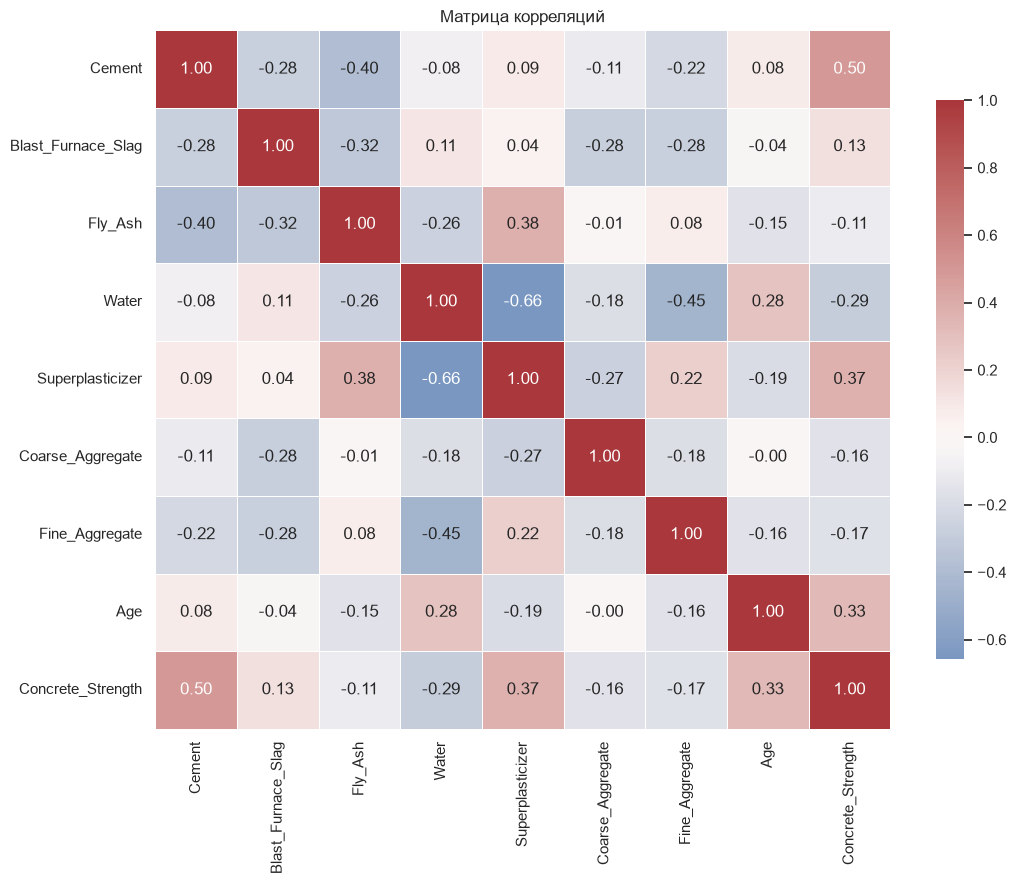

,Корреляция с Concrete_Strength
Cement,0.498
Superplasticizer,0.366
Age,0.329
Water,-0.290
Fine_Aggregate,-0.167
Coarse_Aggregate,-0.165
Blast_Furnace_Slag,0.135
Fly_Ash,-0.106


In [8]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Матрица корреляций")
plt.tight_layout()
plt.show()

target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("Корреляция с Concrete_Strength")
)
display(target_corr.round(3))

,Признак,VIF
0,Cement,7.489
1,Blast_Furnace_Slag,7.277
6,Fine_Aggregate,7.005
3,Water,7.005
2,Fly_Ash,6.171
5,Coarse_Aggregate,5.076
4,Superplasticizer,2.965
7,Age,1.118


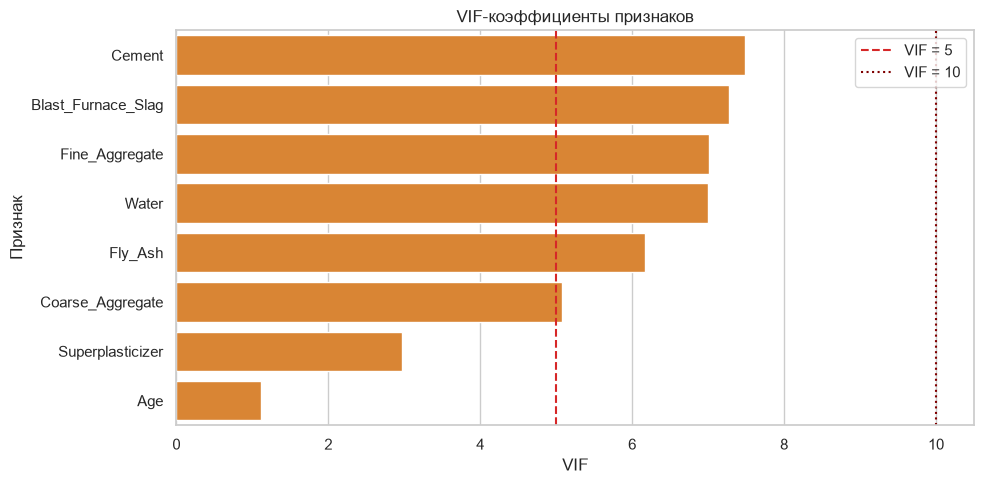

Вывод: признаки с VIF > 5 указывают на заметную мультиколлинеарность: Cement, Blast_Furnace_Slag, Fine_Aggregate, Water, Fly_Ash, Coarse_Aggregate.


In [9]:
X_const = sm.add_constant(X)
vif = pd.DataFrame({
    "Признак": X.columns,
    "VIF": [
        variance_inflation_factor(X_const.values, i)
        for i in range(1, X_const.shape[1])
    ],
}).sort_values("VIF", ascending=False)

display(vif.round(3))

plt.figure(figsize=(10, 5))
sns.barplot(data=vif, x="VIF", y="Признак", color="#F58518")
plt.axvline(5, color="#D62728", linestyle="--", label="VIF = 5")
plt.axvline(10, color="#7F0000", linestyle=":", label="VIF = 10")
plt.title("VIF-коэффициенты признаков")
plt.legend()
plt.tight_layout()
plt.show()

high_vif = vif[vif["VIF"] > 5]
if high_vif.empty:
    print("Вывод: выраженной мультиколлинеарности по VIF не обнаружено.")
else:
    names = ", ".join(high_vif["Признак"].tolist())
    print(
        "Вывод: признаки с VIF > 5 указывают на заметную мультиколлинеарность: "
        f"{names}."
    )

## 5. Линейная и ridge-регрессия на исходных признаках

Для ridge-регрессии признаки стандартизируются, потому что регуляризация чувствительна к масштабу. Для линейной регрессии стандартизация не меняет качество прогноза, но оставлена для единообразия пайплайнов.

Метрики:
- **RMSE**: средняя ошибка прогноза в MPa, чем меньше, тем лучше.
- **R²**: доля объясненной дисперсии, чем ближе к 1, тем лучше.
- **MAPE**: средняя абсолютная процентная ошибка, чем меньше, тем лучше.

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
alphas = np.logspace(-3, 3, 80)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
    "mape": "neg_mean_absolute_percentage_error",
}


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_model(model_name, feature_set, model, X_train, X_test, y_train, y_test, X_all, y_all):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_validate(
        model,
        X_all,
        y_all,
        cv=cv,
        scoring=scoring,
        error_score="raise",
    )

    alpha = np.nan
    estimator = model.named_steps.get("model") if isinstance(model, Pipeline) else model
    if hasattr(estimator, "alpha_"):
        alpha = float(estimator.alpha_)

    return {
        "Модель": model_name,
        "Признаки": feature_set,
        "Кол-во признаков": X_train.shape[1],
        "alpha Ridge": alpha,
        "Test RMSE": rmse(y_test, y_pred),
        "Test R²": r2_score(y_test, y_pred),
        "Test MAPE, %": mean_absolute_percentage_error(y_test, y_pred) * 100,
        "CV RMSE mean": -cv_scores["test_rmse"].mean(),
        "CV RMSE std": cv_scores["test_rmse"].std(),
        "CV R² mean": cv_scores["test_r2"].mean(),
        "CV MAPE mean, %": -cv_scores["test_mape"].mean() * 100,
    }, model, y_pred


linear_original = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

ridge_original = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas, cv=cv, scoring="neg_root_mean_squared_error")),
])

rows = []
fitted_models = {}
predictions = {}

for name, model in [
    ("Linear Regression", linear_original),
    ("Ridge Regression", ridge_original),
]:
    row, fitted, pred = evaluate_model(
        name,
        "Исходные признаки",
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        X,
        y,
    )
    rows.append(row)
    fitted_models[(name, "Исходные признаки")] = fitted
    predictions[(name, "Исходные признаки")] = pred

results_original = pd.DataFrame(rows)
display(results_original.round(4))

,Модель,Признаки,Кол-во признаков,alpha Ridge,Test RMSE,Test R²,"Test MAPE, %",CV RMSE mean,CV RMSE std,CV R² mean,"CV MAPE mean, %"
0,Linear Regression,Исходные признаки,8,NaN,9.7967,0.6275,29.2763,10.5050,0.8092,0.6006,31.7488
1,Ridge Regression,Исходные признаки,8,0.3209,9.7965,0.6276,29.2975,10.5109,0.8108,0.6002,31.8127


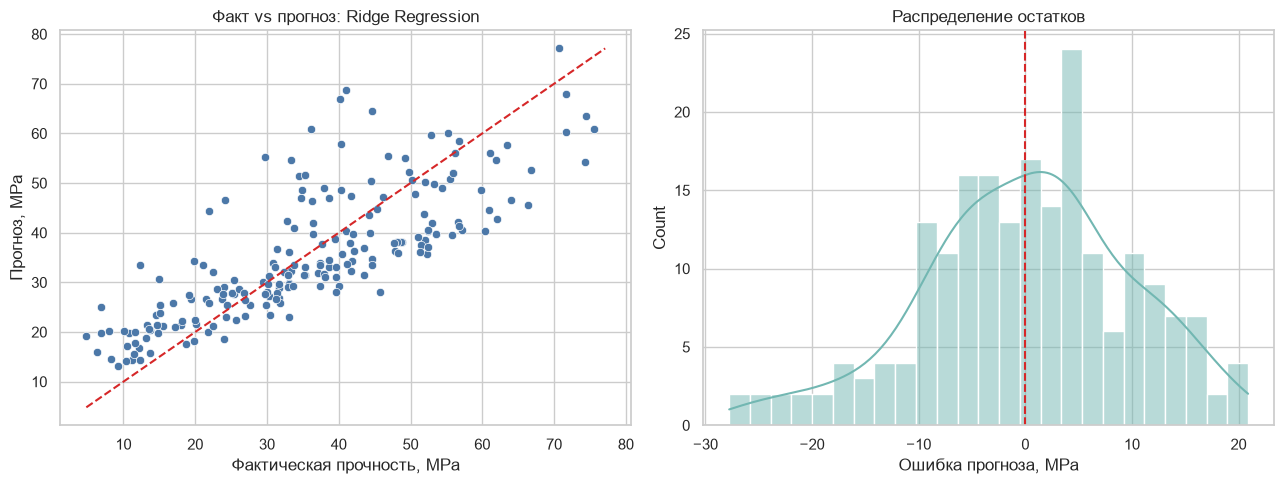

In [11]:
best_original_key = min(
    predictions,
    key=lambda key: rmse(y_test, predictions[key])
    if key[1] == "Исходные признаки"
    else np.inf,
)
best_original_pred = predictions[best_original_key]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=best_original_pred, ax=axes[0], color="#4C78A8")
min_val = min(y_test.min(), best_original_pred.min())
max_val = max(y_test.max(), best_original_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "--", color="#D62728")
axes[0].set_title(f"Факт vs прогноз: {best_original_key[0]}")
axes[0].set_xlabel("Фактическая прочность, MPa")
axes[0].set_ylabel("Прогноз, MPa")

residuals = y_test - best_original_pred
sns.histplot(residuals, kde=True, bins=25, ax=axes[1], color="#72B7B2")
axes[1].axvline(0, color="#D62728", linestyle="--")
axes[1].set_title("Распределение остатков")
axes[1].set_xlabel("Ошибка прогноза, MPa")

plt.tight_layout()
plt.show()

## 6. PCA: стандартизация и снижение размерности

PCA строится после стандартизации признаков. Число компонент выбирается по обучающей выборке: берем минимальное число компонент, объясняющее не менее 95% дисперсии. Это снижает риск утечки информации из тестовой выборки.

,Компонента,Доля дисперсии,Накопленная доля
0,PC1,0.2802,0.2802
1,PC2,0.1791,0.4593
2,PC3,0.1683,0.6276
3,PC4,0.1280,0.7556
4,PC5,0.1181,0.8737
5,PC6,0.0994,0.9731
6,PC7,0.0230,0.9961
7,PC8,0.0039,1.0000


Выбрано компонент: 6 из 8 (накопленная дисперсия: 97.31%)


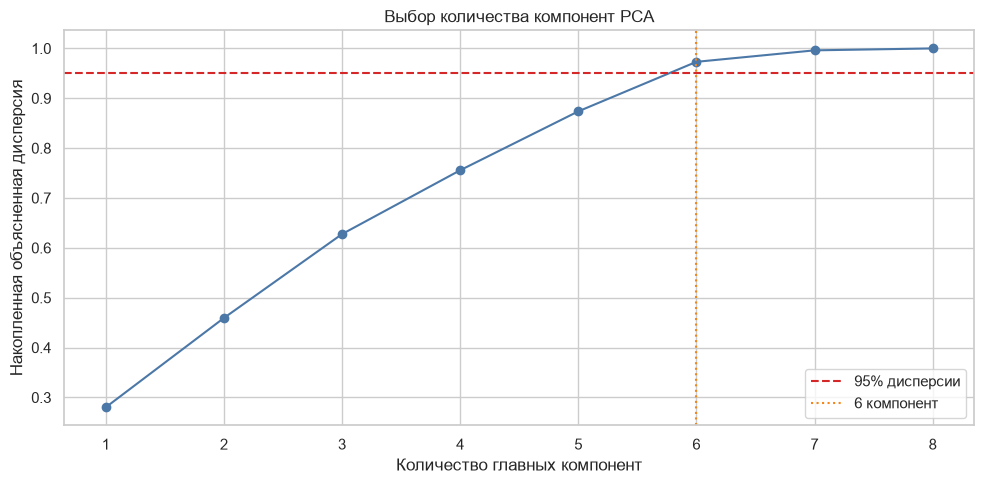

In [12]:
scaler_for_pca = StandardScaler()
X_train_scaled = scaler_for_pca.fit_transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)

pca_table = pd.DataFrame({
    "Компонента": [f"PC{i}" for i in range(1, len(explained) + 1)],
    "Доля дисперсии": explained,
    "Накопленная доля": cumulative,
})
display(pca_table.round(4))
print(
    f"Выбрано компонент: {n_components_95} из {X.shape[1]} "
    f"(накопленная дисперсия: {cumulative[n_components_95 - 1]:.2%})"
)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o", color="#4C78A8")
plt.axhline(0.95, color="#D62728", linestyle="--", label="95% дисперсии")
plt.axvline(n_components_95, color="#F58518", linestyle=":", label=f"{n_components_95} компонент")
plt.xticks(range(1, len(cumulative) + 1))
plt.xlabel("Количество главных компонент")
plt.ylabel("Накопленная объясненная дисперсия")
plt.title("Выбор количества компонент PCA")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Линейная и ridge-регрессия на главных компонентах

В этих моделях исходные признаки заменяются главными компонентами. Стандартизация и PCA находятся внутри `Pipeline`, поэтому на кросс-валидации и тесте преобразования обучаются только на тренировочной части.

In [13]:
linear_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_95, random_state=RANDOM_STATE)),
    ("model", LinearRegression()),
])

ridge_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_95, random_state=RANDOM_STATE)),
    ("model", RidgeCV(alphas=alphas, cv=cv, scoring="neg_root_mean_squared_error")),
])

rows_pca = []
for name, model in [
    ("Linear Regression", linear_pca),
    ("Ridge Regression", ridge_pca),
]:
    row, fitted, pred = evaluate_model(
        name,
        "PCA-компоненты",
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        X,
        y,
    )
    row["Кол-во признаков"] = n_components_95
    rows_pca.append(row)
    fitted_models[(name, "PCA-компоненты")] = fitted
    predictions[(name, "PCA-компоненты")] = pred

results_pca = pd.DataFrame(rows_pca)
results = pd.concat([results_original, results_pca], ignore_index=True)
display(results.round(4))

,Модель,Признаки,Кол-во признаков,alpha Ridge,Test RMSE,Test R²,"Test MAPE, %",CV RMSE mean,CV RMSE std,CV R² mean,"CV MAPE mean, %"
0,Linear Regression,Исходные признаки,8,NaN,9.7967,0.6275,29.2763,10.5050,0.8092,0.6006,31.7488
1,Ridge Regression,Исходные признаки,8,0.3209,9.7965,0.6276,29.2975,10.5109,0.8108,0.6002,31.8127
2,Linear Regression,PCA-компоненты,6,NaN,10.5515,0.5679,32.6175,11.1129,0.9877,0.5547,34.2442
3,Ridge Regression,PCA-компоненты,6,4.4215,10.5507,0.5680,32.7159,11.1200,0.9819,0.5542,34.6170


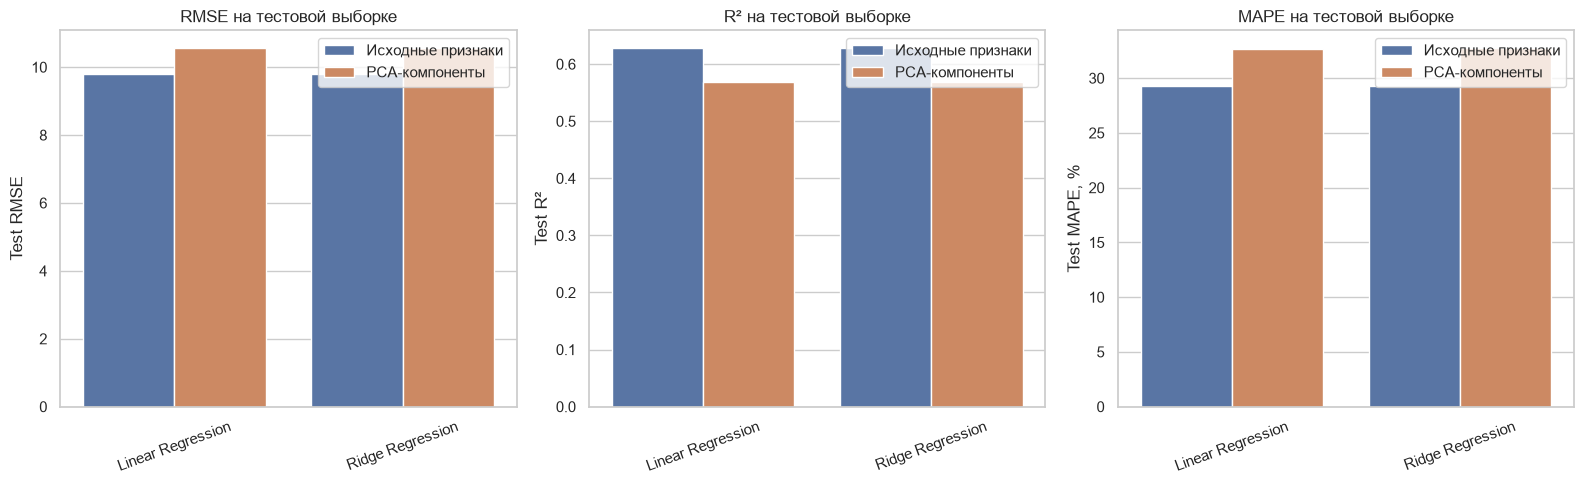

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=results, x="Модель", y="Test RMSE", hue="Признаки", ax=axes[0])
axes[0].set_title("RMSE на тестовой выборке")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results, x="Модель", y="Test R²", hue="Признаки", ax=axes[1])
axes[1].set_title("R² на тестовой выборке")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=results, x="Модель", y="Test MAPE, %", hue="Признаки", ax=axes[2])
axes[2].set_title("MAPE на тестовой выборке")
axes[2].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.set_xlabel("")
    ax.legend(title="")

plt.tight_layout()
plt.show()

## 8. Автоматизированные выводы

In [15]:
best = results.sort_values("Test RMSE").iloc[0]
original_best = results[results["Признаки"] == "Исходные признаки"].sort_values("Test RMSE").iloc[0]
pca_best = results[results["Признаки"] == "PCA-компоненты"].sort_values("Test RMSE").iloc[0]

print("Выводы:")
print(f"1. В датасете {len(df)} наблюдений и {X.shape[1]} исходных количественных признаков; пропуски отсутствуют.")
print(
    "2. По VIF заметная мультиколлинеарность есть у признаков: "
    + (", ".join(high_vif["Признак"].tolist()) if not high_vif.empty else "не обнаружена")
    + "."
)
print(
    f"3. PCA снизил размерность с {X.shape[1]} до {n_components_95} компонент "
    f"при сохранении {cumulative[n_components_95 - 1]:.2%} дисперсии обучающей выборки."
)
print(
    f"4. Лучшая модель по Test RMSE: {best['Модель']} ({best['Признаки']}) "
    f"с RMSE={best['Test RMSE']:.3f}, R²={best['Test R²']:.3f}, "
    f"MAPE={best['Test MAPE, %']:.2f}%."
)

rmse_delta = pca_best["Test RMSE"] - original_best["Test RMSE"]
if rmse_delta <= 0:
    print(
        f"5. Лучший PCA-вариант улучшил RMSE относительно лучшей модели на исходных признаках "
        f"на {abs(rmse_delta):.3f} MPa."
    )
else:
    print(
        f"5. Лучший PCA-вариант уступил лучшей модели на исходных признаках "
        f"на {rmse_delta:.3f} MPa по RMSE, но использует меньше признаков."
    )
print("6. Целевая переменная количественная, поэтому логистическая регрессия здесь не применяется.")

Выводы:
1. В датасете 1030 наблюдений и 8 исходных количественных признаков; пропуски отсутствуют.
2. По VIF заметная мультиколлинеарность есть у признаков: Cement, Blast_Furnace_Slag, Fine_Aggregate, Water, Fly_Ash, Coarse_Aggregate.
3. PCA снизил размерность с 8 до 6 компонент при сохранении 97.31% дисперсии обучающей выборки.
4. Лучшая модель по Test RMSE: Ridge Regression (Исходные признаки) с RMSE=9.797, R²=0.628, MAPE=29.30%.
5. Лучший PCA-вариант уступил лучшей модели на исходных признаках на 0.754 MPa по RMSE, но использует меньше признаков.
6. Целевая переменная количественная, поэтому логистическая регрессия здесь не применяется.


## Итог

Линейная регрессия дает базовую интерпретируемую модель зависимости прочности бетона от состава смеси и возраста. Ridge-регрессия добавляет регуляризацию и помогает стабилизировать модель при мультиколлинеарности. PCA устраняет линейную зависимость между признаками-компонентами и уменьшает размерность, после чего качество нужно сравнивать по тестовым метрикам: выигрыш в простоте признакового пространства не всегда означает улучшение прогноза.